# Character GPT - completed GPU run

Srinidhi, Lab Pair 49. This executed notebook displays preserved training outputs and verifies the saved checkpoint. Training ran on the recorded RunPod GPU; notebook rendering can run locally. The accompanying gpt.py contains the from-scratch model and training implementation.

In [1]:
from pathlib import Path
import json
import pandas as pd
from IPython.display import display, Image
ROOT = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / "pyproject.toml").is_file())
RUN = ROOT / 'reproducibility/raw_logs/srinidhi/runpod-20260918/part-a-full-b256'
summary = json.loads((RUN / "summary.json").read_text())
config = json.loads((RUN / "config.json").read_text())
assert summary["is_final_training_run"]
display({"training_gpu": summary["device_name"], "torch": summary["torch_version"],
         "cuda": summary["cuda_version"], "epochs": summary["completed_full_epochs"],
         "train_stories": summary["train_stories"], "validation_stories": summary["validation_stories"]})
display(config)

{'training_gpu': 'NVIDIA GeForce RTX 4090',
 'torch': '2.11.0+cu128',
 'cuda': '12.8',
 'epochs': 12,
 'train_stories': 100000,
 'validation_stories': 10000}

{'mode': 'full',
 'seed': 2342,
 'dataset': 'roneneldan/TinyStories',
 'dataset_revision': 'main',
 'selection': 'indexed_permutation',
 'shuffle_buffer': 1000,
 'data_cache': 'task1_llm/srinidhi/data_processed/full',
 'raw_data_cache': 'task1_llm/data/huggingface',
 'offline': True,
 'train_stories': 100000,
 'validation_stories': 10000,
 'layers': 3,
 'heads': 6,
 'embedding_dim': 192,
 'feedforward_dim': 768,
 'context_length': 256,
 'dropout': 0.15,
 'batch_size': 256,
 'learning_rate': 0.0004,
 'adam_betas': [0.9, 0.95],
 'weight_decay': 0.01,
 'warmup_fraction': 0.05,
 'minimum_lr_ratio': 0.1,
 'epochs': 12,
 'max_steps': None,
 'gradient_clip': 1.0,
 'mixed_precision': True,
 'deterministic': True,
 'num_workers': 0,
 'cpu_threads': 2,
 'log_every_steps': 50,
 'checkpoint_every_steps': 250,
 'generation_prompts': 5,
 'generation_characters': 256,
 'temperature': 0.8,
 'top_k': 40}

## Measured metrics

Metrics come from the selected validation checkpoint. Timing and memory describe the whole run. See results.md for metric definitions and limitations.

In [2]:
display(pd.read_csv(ROOT / "task1_llm/srinidhi/metrics_report.csv")[["split", "metric", "value"]])

,split,metric,value
0,train,cross_entropy,7.972367e-01
1,train,perplexity,2.219400e+00
2,train,bits_per_character,1.150169e+00
3,train,next_character_accuracy,7.490521e-01
4,train,scored_targets_including_eos,8.957479e+07
5,validation,cross_entropy,7.196820e-01
6,validation,perplexity,2.053780e+00
7,validation,bits_per_character,1.038282e+00
8,validation,next_character_accuracy,7.737605e-01
9,validation,scored_targets_including_eos,8.718099e+06


learning_curves.png


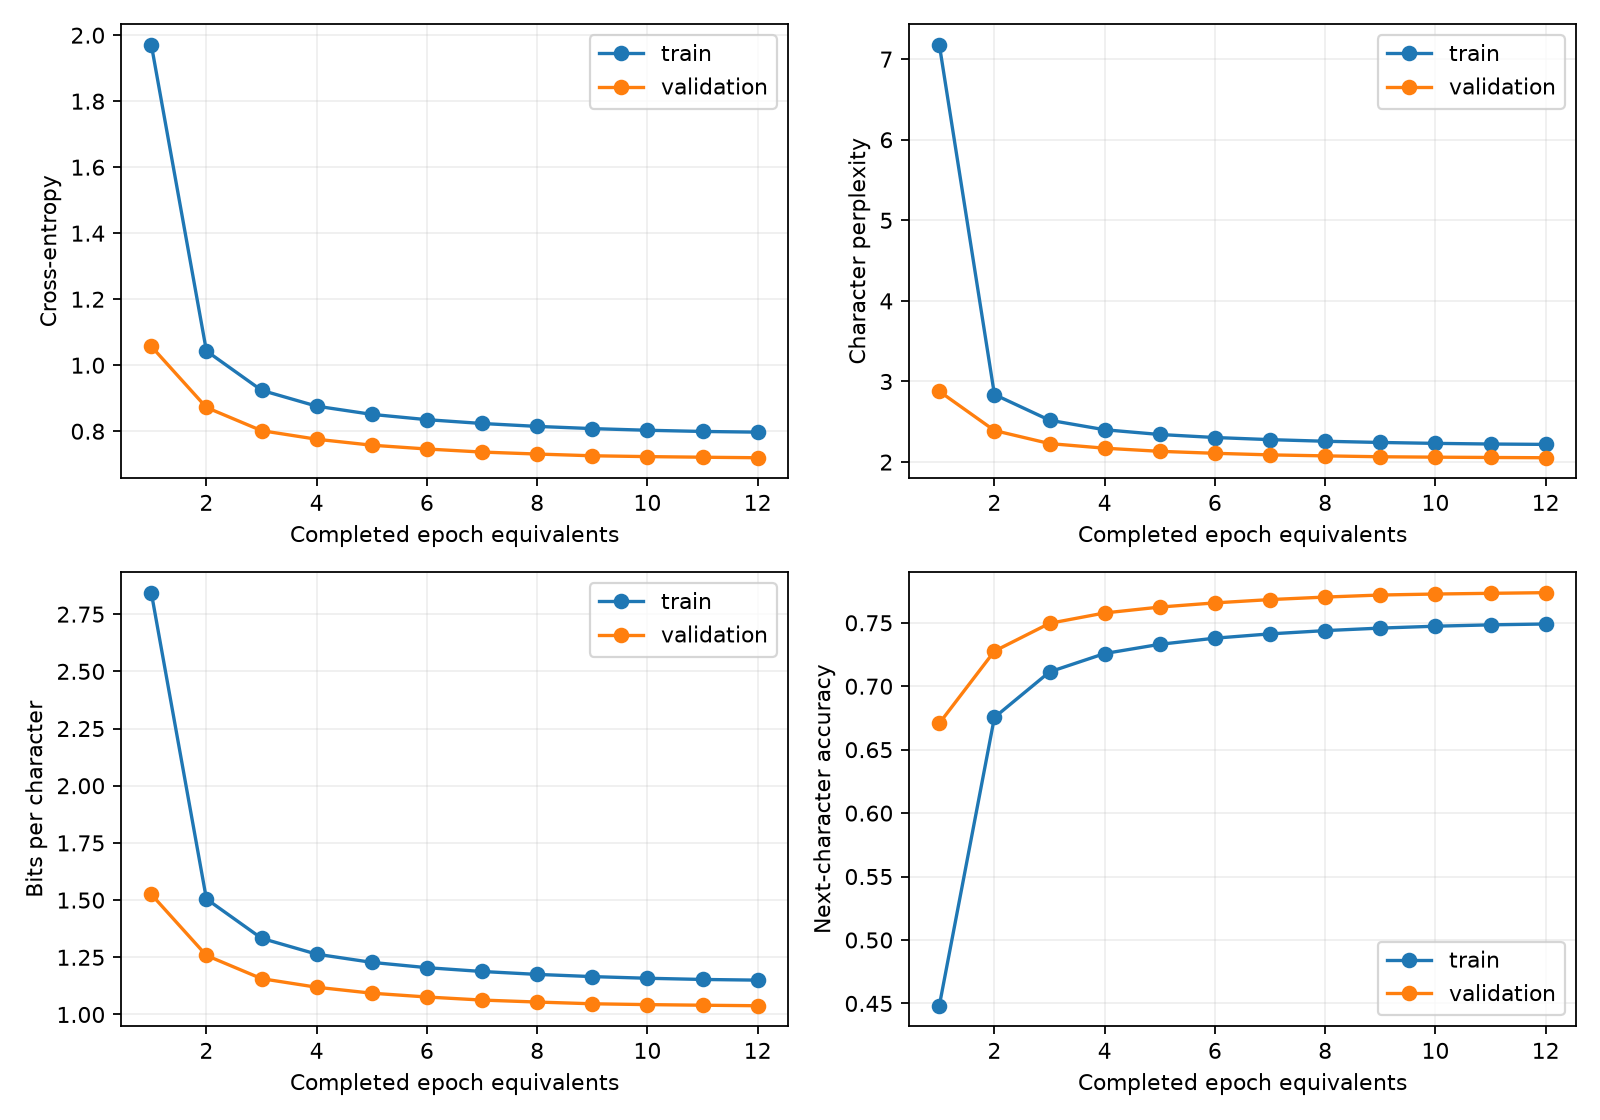

training_diagnostics.png


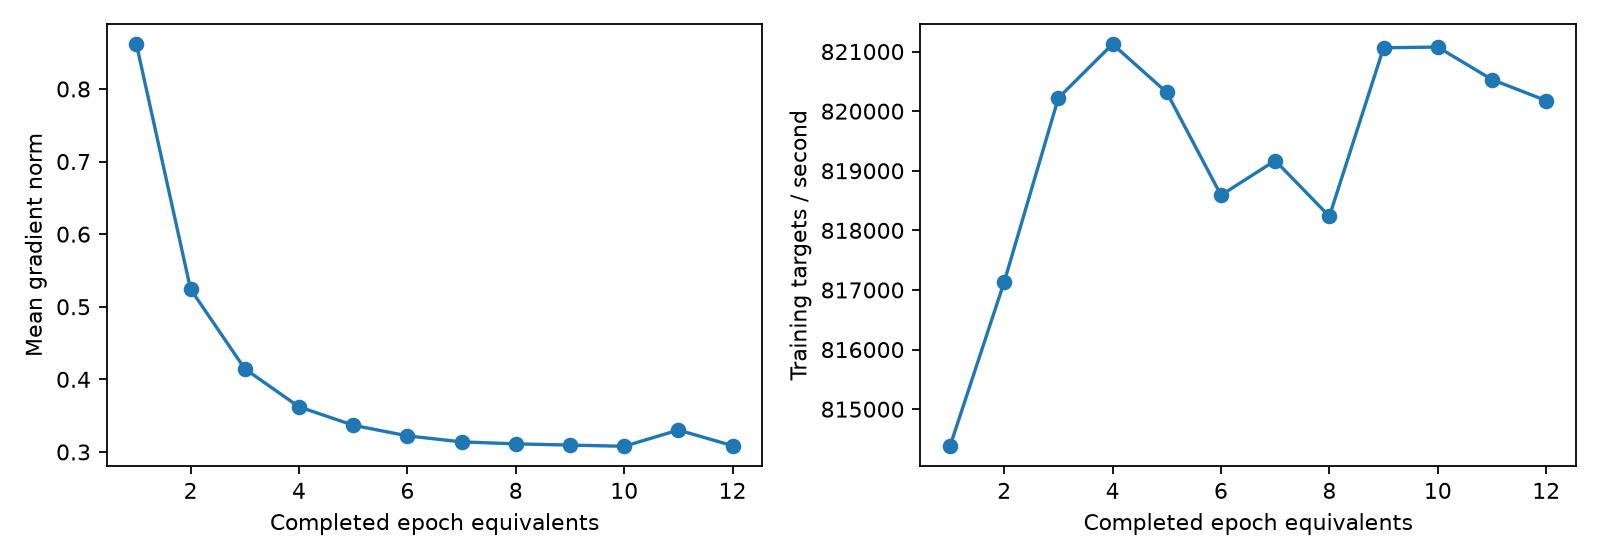

In [3]:
for figure in sorted((RUN / "figures").glob("*.png")):
    print(figure.name)
    display(Image(filename=str(figure), width=850))

## Actual generated stories

In [4]:
generations = json.loads((RUN / "generations.json").read_text())
for index, item in enumerate(generations):
    print(f"{index}: {item['decoding']} | {item['generation_tokens_per_second']:.1f} characters/sec")
    print(item["full_text"])
    print()

0: greedy | 227.9 characters/sec
Once upon a time, a little bird named Timmy went to the park. They saw a big box of colors and a big box. Timmy was very happy and he wanted to see the box. He said, "Let's go to the box, Timmy. We can go to the box." Timmy was so happy to have a new color to see the box. He was so happ

1: sampled | 213.9 characters/sec
Once upon a time, a little bird named Timmy went to the park. Timmy was very excited, but he couldn't fly away. He tried to go fast and he couldn't understand his parents again. But, he was not happy to see his unusual sound or remember his parents worked.

Timmy was sad because he didn

2: greedy | 236.8 characters/sec
Lily found a small red box. Inside the box was a big box with a big smile. She was very happy and said, "Lily, you can have a big smile on the swing. You can have a small box of cookies and share them with me."

Lily was so happy to have a small box of cookies. She said, "Thank you, mom. Y

3: sampled | 222.6 characters/

# Srinidhi — Character GPT failure analysis

These observations use the actual epoch-12 checkpoint and the zero-based entries in `outputs/full/generations.json`. This is an AI-assisted analysis draft for student review; it does not claim that the student has already reviewed the model.

## 1. Repetition: generation 4, greedy

> He wanted to go outside and play with his friends. He wanted to go outside and play with his friends.

The same sentence appears twice consecutively and then returns again later. The story stops developing Tom's original goal of helping his friend. Greedy decoding repeatedly picks the most likely next character, which can reinforce a common phrase. The limited model and context may also contribute; this run does not isolate the cause.

A useful next experiment is to compare sampling and a small repetition penalty using the same prompts and checkpoint. Measure repeated 4-grams and inspect whether the story still makes sense. A lower repetition score alone does not establish better writing.

## 2. Broken grammar: generation 7, sampled

> The dog chased it on, and touched it broke.

The clauses do not form a grammatical description of an action, and the object of the action is unclear. This occurs within the generated continuation, not at the imposed length cutoff. Character-level predictions can spell common words while failing to combine them into a meaningful sentence. Sampling adds variation but can also select a less plausible continuation.

A useful next experiment is to reduce the temperature from 0.8 to 0.6 while keeping top-k at 40, then compare several fixed prompts for grammar and repetition. That change has not been tested here.

## 3. Character identity drift: generation 5, sampled

> His friend looked at him and said, "I don't know, Lily. I will be happy. I will be very excited."

The prompt names Tom, but the dialogue addresses Lily without introducing her. The text loses track of the established character. A 256-character attention window limits accessible context, and next-character prediction does not explicitly enforce character consistency. These are plausible explanations rather than demonstrated causal findings.

A useful next experiment is to compare a longer context at a similar training budget and manually track names across the same prompts. Keep this separate from a decoding-only experiment so the source of any improvement is clearer.

## What the metrics do and do not show

Validation cross-entropy improved to 0.7197 and character perplexity to 2.0538, but those next-character metrics do not guarantee coherent stories. Across the five fixed prompts, the repeated 4-gram fraction is 0.1956 with greedy decoding and 0.0207 with sampling. Sampled text has more variety, yet the grammar and identity examples show remaining weaknesses. This is a small qualitative sample, not an estimate of the failure rate over all stories.

Every continuation is capped at 256 emitted characters. A trailing partial word or unfinished sentence at that boundary is an evaluation length limit and is not counted as a separate model failure here. The reported negative train-validation loss gap also compares training with dropout against validation without dropout; it should not be interpreted as a matched estimate of generalization.


## Checkpoint and raw evidence

In [5]:
import hashlib
import torch
folder = ROOT / "task1_llm/srinidhi/checkpoints"
manifest = json.loads((folder / "manifest.json").read_text())
for name, info in manifest.items():
    assert hashlib.sha256((folder / name).read_bytes()).hexdigest() == info["sha256"]
saved = torch.load(folder / "best.pt", map_location="cpu", weights_only=False)
assert all(torch.isfinite(value).all() for value in saved["model"].values())
print("Both checkpoint checksums verified; best model tensors are finite.")
print("Recorded same-device GPU inference reload:", summary["inference_reload_verified"])
print("Raw evidence:", RUN.relative_to(ROOT))
print((RUN / "RUN_LOG.txt").read_text()[-4000:])

Both checkpoint checksums verified; best model tensors are finite.
Recorded same-device GPU inference reload: True
Raw evidence: reproducibility/raw_logs/srinidhi/runpod-20260918/part-a-full-b256
0.8049 elapsed=1364.6s eta_steps_est=143.5s
gpt/full epoch=11/12 batch=1390/1561 step=17000/18732 loss=0.8109 elapsed=1368.4s eta_steps_est=139.4s
gpt/full epoch=11/12 batch=1440/1561 step=17050/18732 loss=0.8081 elapsed=1372.4s eta_steps_est=135.4s
gpt/full epoch=11/12 batch=1490/1561 step=17100/18732 loss=0.8202 elapsed=1376.3s eta_steps_est=131.3s
gpt/full epoch=11/12 batch=1540/1561 step=17150/18732 loss=0.7941 elapsed=1380.1s eta_steps_est=127.3s
gpt/full epoch=11 validating
gpt/full epoch=11 train_loss=0.7993 val_loss=0.7213 val_perplexity=2.0570
gpt/full epoch=12/12 batch=29/1561 step=17200/18732 loss=0.7933 elapsed=1388.9s eta_steps_est=123.7s
gpt/full epoch=12/12 batch=79/1561 step=17250/18732 loss=0.7729 elapsed=1392.7s eta_steps_est=119.7s
gpt/full epoch=12/12 batch=129/1561 step=17

## Reload and run the saved model locally

This fresh CPU inference is a portability check. It is separate from the recorded GPU timing metrics.

In [6]:
from lab1.gpt import CharacterGPT, generate
torch.set_num_threads(2)
model = CharacterGPT(len(saved["vocabulary"]["tokens"]), saved["config"])
model.load_state_dict(saved["model"], strict=True)
model.eval()
assert sum(p.numel() for p in model.parameters()) == summary["parameter_count"]
print(model)
prompt = "Once upon a time, a little bird"
continuation = generate(model, saved["vocabulary"], prompt, 120, torch.device("cpu"),
                        seed=2342, temperature=0)
print("Fresh CPU checkpoint inference:")
print(prompt + continuation)

CharacterGPT(
  (token_embedding): Embedding(114, 192, padding_idx=0)
  (position_embedding): Embedding(256, 192)
  (embedding_dropout): Dropout(p=0.15, inplace=False)
  (blocks): ModuleList(
    (0-2): 3 x TransformerBlock(
      (norm1): LayerNorm((192,), eps=1e-05, elementwise_affine=True)
      (attention): ManualCausalAttention(
        (qkv): Linear(in_features=192, out_features=576, bias=True)
        (projection): Linear(in_features=192, out_features=192, bias=True)
        (attention_dropout): Dropout(p=0.15, inplace=False)
        (output_dropout): Dropout(p=0.15, inplace=False)
      )
      (norm2): LayerNorm((192,), eps=1e-05, elementwise_affine=True)
      (feedforward): Sequential(
        (0): Linear(in_features=192, out_features=768, bias=True)
        (1): GELU(approximate='none')
        (2): Linear(in_features=768, out_features=192, bias=True)
        (3): Dropout(p=0.15, inplace=False)
      )
    )
  )
  (final_norm): LayerNorm((192,), eps=1e-05, elementwise_affin

Fresh CPU checkpoint inference:
Once upon a time, a little bird named Timmy went to the park. They saw a big box of colors and a big box. Timmy was very happy and he wanted to see the


## Reproduce

Run from the repository root after setup and preparing the frozen data:

```bash
.venv/bin/python -m lab1.run --task gpt --mode full --device cuda --set offline=true
```

This starts a new full training run. The one-command CPU smoke test is documented in the root README. See failure_analysis.md for observed errors and review the explanation before the viva.